[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/digitalopentech/kaggle-huggingface/blob/main/hf-spaces/hodgkin-huxley/hodgkin-huxley.ipynb)  ·  [Página renderizada](https://huggingface.co/spaces/leonardovalle/hodgkin-huxley-potencial-de-acao)

# ⚡ O Potencial de Ação: simulando o modelo de Hodgkin-Huxley

Em 1952, **Alan Hodgkin e Andrew Huxley** publicaram um conjunto de equações que descreve,
com precisão quantitativa, como um neurônio dispara — o **potencial de ação**. O trabalho,
feito com eletrodos no axônio gigante de lula, rendeu o **Nobel de 1963** e fundou a
neurociência computacional: até hoje é o modelo biofísico de referência.

**A ideia central:** a membrana do neurônio é um capacitor com canais iônicos que funcionam
como condutâncias dependentes de voltagem:

- Canais de **sódio (Na⁺)** abrem rápido e despolarizam a célula (subida do spike);
- Canais de **potássio (K⁺)** abrem devagar e repolarizam (descida);
- A **inativação** do Na⁺ (variável *h*) encerra o spike e cria o período refratário.

$$C_m \frac{dV}{dt} = I_{ext} - \bar{g}_{Na} m^3 h\,(V - E_{Na}) - \bar{g}_K n^4 (V - E_K) - \bar{g}_L (V - E_L)$$

$$\frac{dx}{dt} = \alpha_x(V)\,(1 - x) - \beta_x(V)\,x, \qquad x \in \{m, h, n\}$$

Neste notebook implementamos o modelo do zero (NumPy puro) e reproduzimos **quatro
experimentos clássicos**:

1. A anatomia de um spike (correntes de Na⁺ e K⁺ em ação)
2. O disparo **tudo-ou-nada** (limiar)
3. A **curva F-I** (código de taxa: como a corrente vira frequência)
4. O **período refratário**

*Referências ao final. Parâmetros originais de Hodgkin & Huxley (1952), axônio de lula a 6,3 °C.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 1.4,
})
AZUL, LARANJA, VERDE, ROSA, CINZA = "#0072B2", "#D55E00", "#009E73", "#CC79A7", "#B9BDC1"

# ── Parâmetros de Hodgkin & Huxley (1952) ──
C_m  = 1.0                       # capacitância da membrana (µF/cm²)
g_Na, g_K, g_L = 120.0, 36.0, 0.3   # condutâncias máximas (mS/cm²)
E_Na, E_K, E_L = 50.0, -77.0, -54.387  # potenciais de reversão (mV)

def alpha_m(V): return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10) + 1e-12)
def beta_m(V):  return 4.0 * np.exp(-(V + 65) / 18)
def alpha_h(V): return 0.07 * np.exp(-(V + 65) / 20)
def beta_h(V):  return 1.0 / (1 + np.exp(-(V + 35) / 10))
def alpha_n(V): return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10) + 1e-12)
def beta_n(V):  return 0.125 * np.exp(-(V + 65) / 80)

def simular(I_ext, T=100.0, dt=0.01, V0=-65.0):
    """Integra o modelo HH (Euler). I_ext: função t -> corrente (escalar ou vetor).
    Aceita simulações em lote: se I_ext(t) devolve vetor, tudo roda vetorizado."""
    n_passos = int(T / dt)
    forma = np.shape(I_ext(0.0))
    V = np.full(forma, V0, dtype=float) if forma else V0
    m = alpha_m(V) / (alpha_m(V) + beta_m(V))
    h = alpha_h(V) / (alpha_h(V) + beta_h(V))
    n = alpha_n(V) / (alpha_n(V) + beta_n(V))
    reg = {"t": np.arange(n_passos) * dt, "V": [], "m": [], "h": [], "n": [], "INa": [], "IK": []}
    for i in range(n_passos):
        I_Na = g_Na * m**3 * h * (V - E_Na)
        I_K  = g_K  * n**4     * (V - E_K)
        I_L  = g_L             * (V - E_L)
        V = V + dt * (I_ext(i * dt) - I_Na - I_K - I_L) / C_m
        m = m + dt * (alpha_m(V) * (1 - m) - beta_m(V) * m)
        h = h + dt * (alpha_h(V) * (1 - h) - beta_h(V) * h)
        n = n + dt * (alpha_n(V) * (1 - n) - beta_n(V) * n)
        for k, v in [("V", V), ("m", m), ("h", h), ("n", n), ("INa", I_Na), ("IK", I_K)]:
            reg[k].append(np.copy(v) if forma else v)
    return {k: (np.array(v) if k != "t" else v) for k, v in reg.items()}

print("Modelo pronto. Repouso ≈ -65 mV; dt = 0,01 ms (Euler).")

Modelo pronto. Repouso ≈ -65 mV; dt = 0,01 ms (Euler).


## 1. A anatomia de um potencial de ação

Injetamos um degrau de corrente (10 µA/cm², de 10 a 40 ms) e observamos as três camadas do
fenômeno: a **voltagem**, as **variáveis de gating** (m = ativação Na⁺, h = inativação Na⁺,
n = ativação K⁺) e as **correntes iônicas** que disputam o controle da membrana.

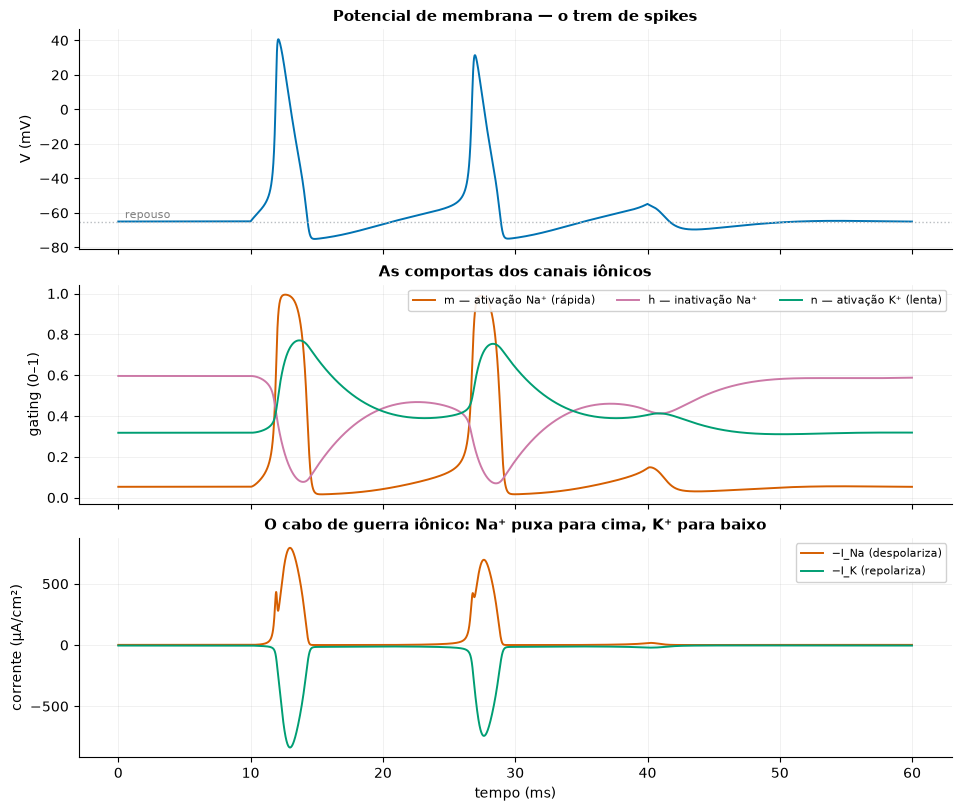

In [2]:
r = simular(lambda t: 10.0 * ((t >= 10) & (t < 40)), T=60)

fig, axes = plt.subplots(3, 1, figsize=(9.5, 8), sharex=True, constrained_layout=True)
axes[0].plot(r["t"], r["V"], color=AZUL)
axes[0].set_ylabel("V (mV)")
axes[0].set_title("Potencial de membrana — o trem de spikes")
axes[0].axhline(-65, color=CINZA, ls=":", lw=1)
axes[0].text(0.5, -63, "repouso", color="gray", fontsize=8)

axes[1].plot(r["t"], r["m"], color=LARANJA, label="m — ativação Na⁺ (rápida)")
axes[1].plot(r["t"], r["h"], color=ROSA, label="h — inativação Na⁺")
axes[1].plot(r["t"], r["n"], color=VERDE, label="n — ativação K⁺ (lenta)")
axes[1].set_ylabel("gating (0–1)")
axes[1].set_title("As comportas dos canais iônicos")
axes[1].legend(fontsize=8, framealpha=0.9, ncols=3)

axes[2].plot(r["t"], -np.array(r["INa"]), color=LARANJA, label="−I_Na (despolariza)")
axes[2].plot(r["t"], -np.array(r["IK"]), color=VERDE, label="−I_K (repolariza)")
axes[2].set_ylabel("corrente (µA/cm²)")
axes[2].set_xlabel("tempo (ms)")
axes[2].set_title("O cabo de guerra iônico: Na⁺ puxa para cima, K⁺ para baixo")
axes[2].legend(fontsize=8, framealpha=0.9);

**Leitura do gráfico:** a cada spike, *m* dispara em <1 ms (Na⁺ entra, V sobe), *h* cai
(o Na⁺ se auto-desliga) enquanto *n* sobe (K⁺ sai, V desce). A hiperpolarização passageira
abaixo do repouso é a assinatura do K⁺ ainda aberto.

## 2. Tudo-ou-nada: o limiar de disparo

Pulsos breves (1 ms) de amplitude crescente: abaixo do limiar a membrana só "murcha" de volta;
acima, o spike completo é produzido — **sempre com a mesma amplitude**. O neurônio não
codifica intensidade na altura do spike.

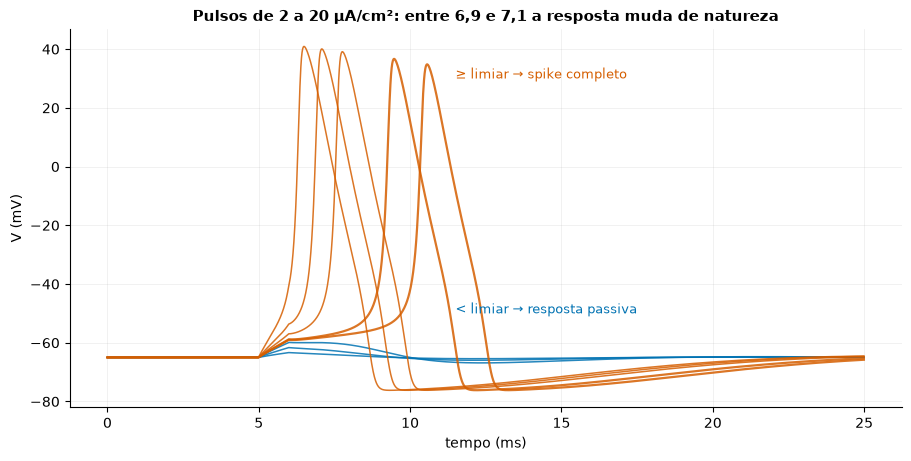

In [3]:
amplitudes = np.array([2, 4, 6, 6.9, 7.1, 9, 12, 20])
r = simular(lambda t: amplitudes * ((t >= 5) & (t < 6)), T=25)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
for j, amp in enumerate(amplitudes):
    disparou = r["V"][:, j].max() > 0
    ax.plot(r["t"], r["V"][:, j], color=LARANJA if disparou else AZUL, alpha=0.85,
            lw=1.6 if abs(amp - 7) < 0.5 else 1.1)
ax.text(11.5, 30, "≥ limiar → spike completo", color=LARANJA, fontsize=9)
ax.text(11.5, -50, "< limiar → resposta passiva", color=AZUL, fontsize=9)
ax.set_xlabel("tempo (ms)"); ax.set_ylabel("V (mV)")
ax.set_title(f"Pulsos de {amplitudes.min():.0f} a {amplitudes.max():.0f} µA/cm²: "
             "entre 6,9 e 7,1 a resposta muda de natureza");

## 3. A curva F-I: como o neurônio codifica intensidade

Se a amplitude do spike é fixa, a informação vai na **frequência**. Varremos correntes
sustentadas e medimos a taxa de disparo (simulação vetorizada: todas as correntes integradas
de uma vez). O modelo HH é um oscilador **Tipo II**: a frequência "nasce" já em ~50 Hz
(início descontínuo, via bifurcação de Hopf) — diferente de neurônios Tipo I, que partem de 0 Hz.

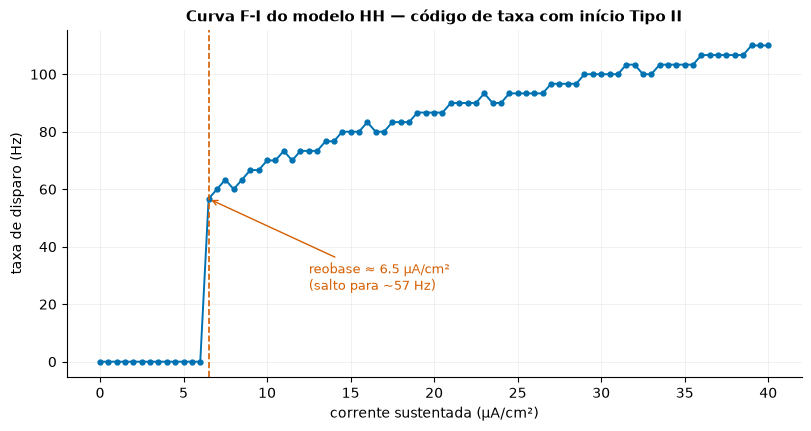

In [4]:
correntes = np.linspace(0, 40, 81)
r = simular(lambda t: correntes * np.ones_like(correntes), T=400)
V = r["V"]
cruzou = (V[:-1] < 0) & (V[1:] >= 0)                 # cruzamentos ascendentes de 0 mV
n_spikes = cruzou[int(100 / 0.01):].sum(axis=0)      # descarta transiente (100 ms)
taxa = n_spikes / 0.3                                # spikes / 300 ms restantes -> Hz

fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
ax.plot(correntes, taxa, color=AZUL, marker="o", ms=3.5)
i_rheo = correntes[np.argmax(taxa > 0)]
ax.axvline(i_rheo, color=LARANJA, ls="--", lw=1.2)
ax.annotate(f"reobase ≈ {i_rheo:.1f} µA/cm²\n(salto para ~{taxa[taxa > 0].min():.0f} Hz)",
            xy=(i_rheo, taxa[taxa > 0].min()), xytext=(i_rheo + 6, 25),
            fontsize=9, color=LARANJA, arrowprops=dict(arrowstyle="->", color=LARANJA))
ax.set_xlabel("corrente sustentada (µA/cm²)")
ax.set_ylabel("taxa de disparo (Hz)")
ax.set_title("Curva F-I do modelo HH — código de taxa com início Tipo II");

## 4. Período refratário: o limite de velocidade do cérebro

Dois pulsos supraliminares separados por um intervalo Δt crescente. Logo após um spike o Na⁺
está inativado (*h* baixo) e o K⁺ ainda aberto: no **período refratário absoluto** nenhum
segundo spike é possível; no **relativo**, ele sai menor. É isso que limita a taxa máxima
de disparo (~ centenas de Hz) e força a propagação unidirecional no axônio.

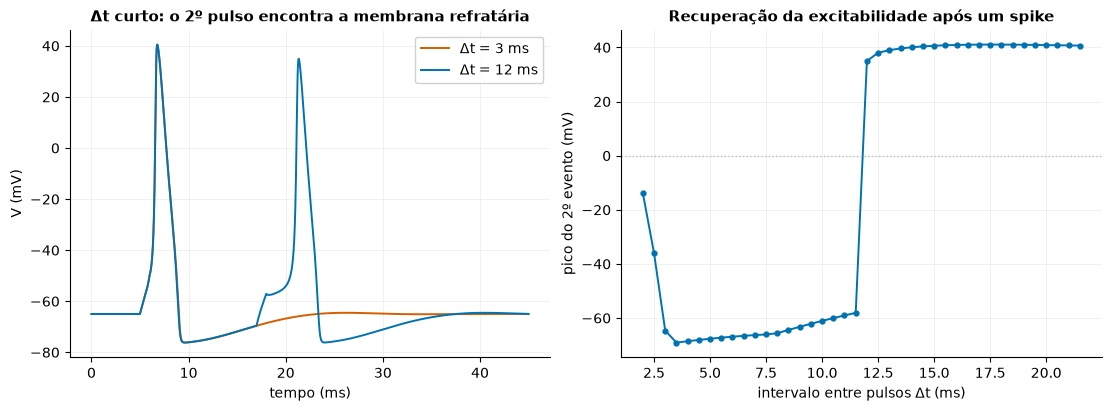

In [5]:
intervalos = np.arange(2, 22, 0.5)
def dois_pulsos(t):
    p1 = ((t >= 5) & (t < 6)) * 15.0
    p2 = ((t >= 5 + intervalos) & (t < 6 + intervalos)) * 15.0
    return p1 + p2
r = simular(dois_pulsos, T=45)
V = r["V"]

pico2 = np.array([V[int((6 + d) / 0.01):int((6 + d + 8) / 0.01), j].max()
                  for j, d in enumerate(intervalos)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for d, cor in [(3.0, LARANJA), (12.0, AZUL)]:
    j = np.argmin(np.abs(intervalos - d))
    axes[0].plot(r["t"], V[:, j], color=cor, label=f"Δt = {d:.0f} ms")
axes[0].set_xlabel("tempo (ms)"); axes[0].set_ylabel("V (mV)")
axes[0].set_title("Δt curto: o 2º pulso encontra a membrana refratária")
axes[0].legend(framealpha=0.9)

axes[1].plot(intervalos, pico2, color=AZUL, marker="o", ms=3.5)
axes[1].axhline(0, color=CINZA, ls=":", lw=1)
axes[1].set_xlabel("intervalo entre pulsos Δt (ms)")
axes[1].set_ylabel("pico do 2º evento (mV)")
axes[1].set_title("Recuperação da excitabilidade após um spike");

## 5. O retrato de fase: o spike como ciclo-limite

Projetando a dinâmica no plano **V × n** (voltagem × ativação do K⁺), o disparo repetitivo
aparece como um **ciclo-limite**: a órbita fechada que o sistema percorre a cada spike. É a
ponte para a teoria de sistemas dinâmicos em neurociência (FitzHugh-Nagumo, Izhikevich).

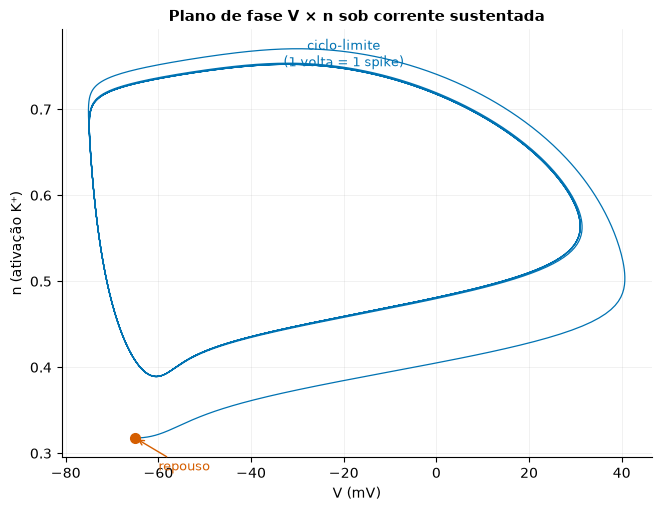

In [6]:
r = simular(lambda t: 10.0 * (t >= 5), T=80)
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)
ax.plot(r["V"], r["n"], color=AZUL, lw=0.9)
ax.plot(r["V"][0], r["n"][0], "o", color=LARANJA, ms=7, zorder=3)
ax.annotate("repouso", xy=(r["V"][0], r["n"][0]), xytext=(-60, 0.28),
            fontsize=9, color=LARANJA, arrowprops=dict(arrowstyle="->", color=LARANJA))
ax.text(-20, 0.75, "ciclo-limite\n(1 volta = 1 spike)", fontsize=9, color=AZUL, ha="center")
ax.set_xlabel("V (mV)"); ax.set_ylabel("n (ativação K⁺)")
ax.set_title("Plano de fase V × n sob corrente sustentada");

## Conclusões

- Quatro equações diferenciais + dados de eletrofisiologia de 1952 reproduzem **spike,
  limiar, código de taxa, refratariedade e o ciclo-limite** — um dos maiores triunfos da
  modelagem quantitativa em biologia.
- A hierarquia de modelos da neurociência computacional nasce aqui: HH (biofísico) →
  FitzHugh-Nagumo (2D) → **LIF** (integra-e-dispara, usado em larga escala) → modelos de taxa.
- Cada mecanismo tem consequência computacional: a inativação do Na⁺ limita a banda de
  transmissão; o início Tipo II molda como a corrente é convertida em frequência.

### Referências
- Hodgkin, A. L. & Huxley, A. F. (1952). *A quantitative description of membrane current and
  its application to conduction and excitation in nerve.* J. Physiol., 117(4), 500–544.
- Izhikevich, E. (2007). *Dynamical Systems in Neuroscience.* MIT Press.
- Dayan, P. & Abbott, L. F. (2001). *Theoretical Neuroscience.* MIT Press.
- Curso aberto Neuromatch Academy — dia **W2D4 (Biological Neuron Models)**:
  https://compneuro.neuromatch.io